# Проект модуля №3 (Ya-Practicum-DLE) `Нейросеть для классификации таблеток`

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import torch
from torchvision.transforms.functional import to_tensor
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip, RandomRotation
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Dataset, DataLoader
import torch.optim as optim

# Метаданные

## флаги отладки
все в `True` в финальном прогоне

In [16]:
verify_images_size = False               # уровень паранои при изучении исходного датасета!

## глобальные параметры

In [ ]:
# датасет был загружен вручную по ссылке из урока и разархивирован в эту папку:
path_dataset_train = os.path.join('.', 'data', 'dataset', 'train')
path_dataset_test = os.path.join('.', 'data', 'dataset', 'test')

# параметры предобработки изображений
crop_half_size = 224 * 2             # размер окна, вырезающего фото вокруг таблетки (уменьшение в 10 раз!)
model_resize_img = 224               # зависит от выбора предобученной сверточной части при сборке модели


# Этап 0. Знакомство с датасетом и EDA
**NB!: (из описания датасета OGYEIv2)** dataset with well-defined conditions: 
* a fixed scale (since size can be important information for recognition), 
* a homogeneous background, 
* and two different illumination settings: 
  * a diffuse light source from above 
  * and alternatively a linear light from a lower elevation on the side to make engravings more visible

## устройство датасета: 
* датасет представляет собой папки с именами классов и картинками объектов данного класса внутри папки
* в корне датасета две папки - `train` и `test` с одинаковым на вид устройством
* убедимся, что наборы `train` и `test` представлены одинаковым набором классов и их имен

In [18]:
train_classes = os.listdir(path_dataset_train)
test_classes = os.listdir(path_dataset_test)
all_classes = set(train_classes + test_classes)

len(train_classes), len(test_classes), len(all_classes)   # если совпали, то пункт 3 выше ОК!

(84, 84, 84)

## сразу создадим кодировщик и декодировщик:
* первый с упорядочиванием имен классов
* второй - строго обратный первому (повторное упорядочивание может не дать тот же порядок - хотя у нас дало бы)

In [19]:
classes_encoder = dict( zip(sorted(list(all_classes)), range(len(all_classes))) )
classes_decoder = dict( zip(classes_encoder.values(), classes_encoder.keys()) )

for tabl in classes_decoder.items():
    print(tabl)
    if tabl[0] > 3: break

(0, 'acc_long_600_mg')
(1, 'advil_ultra_forte')
(2, 'akineton_2_mg')
(3, 'algoflex_forte_dolo_400_mg')
(4, 'algoflex_rapid_400_mg')


## сколько объектов в датасете до аугментации изображений

In [20]:
data_view = pd.DataFrame(
    index=['nof_train_objects', 'nof_test_objects'],
    data=[
        [len(os.listdir(os.path.join(path_dataset_train, cl_name))) for cl_name in classes_encoder],
        [len(os.listdir(os.path.join(path_dataset_test, cl_name))) for cl_name in classes_encoder]
    ]
).T
print('  per-class statistics of the dataset')
data_view.describe()

  per-class statistics of the dataset


,nof_train_objects,nof_test_objects
count,84.0,84.0
mean,28.0,6.0
std,0.0,0.0
min,28.0,6.0
25%,28.0,6.0
50%,28.0,6.0
75%,28.0,6.0
max,28.0,6.0


## посмотрим примеры изображений

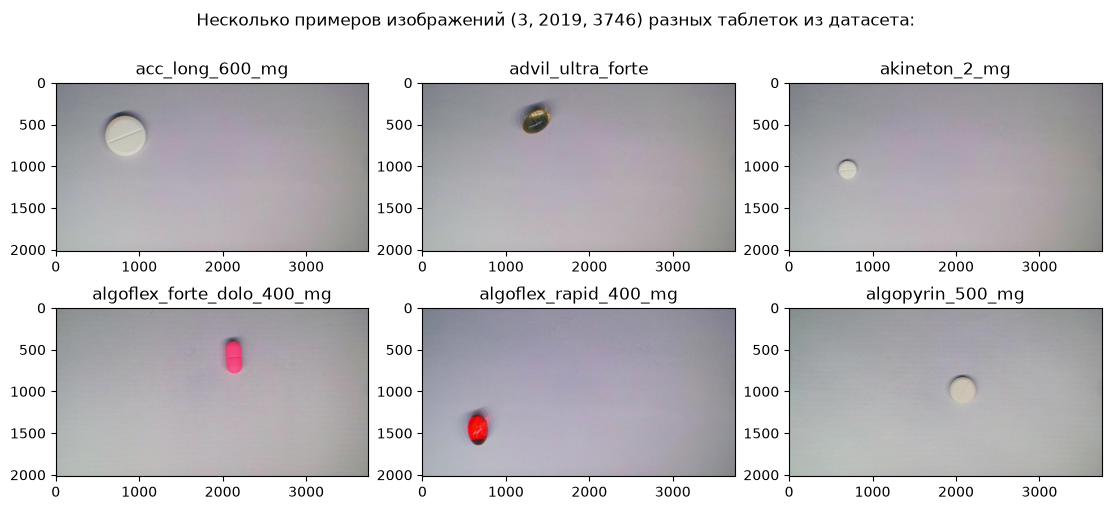

In [21]:
fig, axes = plt.subplots(2,3, figsize=(11,5), layout='constrained')
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = Image.open(os.path.join(
                path_dataset_test,
                classes_decoder[i],
                os.listdir(os.path.join(path_dataset_test,classes_decoder[i]))[0]))
    ax.imshow(image)
    ax.set_title(classes_decoder[i])

fig.suptitle('Несколько примеров изображений '+
             str(to_tensor(image).detach().numpy().shape)+
             ' разных таблеток из датасета:\n')
plt.show()

**ВЫВОДЫ ИЗ ПРИМЕРОВ ИЗОБРАЖЕНИЙ:**
* таблетки занимают малую долю фото, поэтому сразу применять ресайзинг означало бы потерять саму таблетку
* хорошо бы еще перед ресайзингом вырезать вокруг таблетки окно фиксированного в исходных пикселах размера (так как пропорции и масштаб нужно сохранить)
* сам ресайзинг хорошо бы делать макс-пуллингом - чтобы не потерять признаки ярких, но мелких деталей

## проверяем на сколько стабильны параметры изображений в датасете

In [22]:
if verify_images_size:
    train_C_list, train_H_list, train_W_list = [], [], []
    test_C_list, test_H_list, test_W_list = [], [], []

    print()
    print('Проверяем параметры 20% случайных изображений из train dataset:')
    for cl_name in tqdm(classes_encoder):
        tmp_C_list, tmp_H_list, tmp_W_list = [], [], []
    
        for f_idx in range(28):
            if np.random.choice([1]+[0]*4) == 1:               # будем проверять не каждый, а случайные 20%
                c,h,w = to_tensor(Image.open(os.path.join(path_dataset_train, cl_name, 
                                  os.listdir(os.path.join(path_dataset_train, cl_name))[f_idx]))
                                  ).detach().numpy().shape
                tmp_C_list.append(c)
                tmp_H_list.append(h)
                tmp_W_list.append(w)

        train_C_list.append(np.array(tmp_C_list).mean())
        train_H_list.append(np.array(tmp_H_list).mean())
        train_W_list.append(np.array(tmp_W_list).mean())

    print()
    print('Проверяем параметры всех изображений из test dataset:')
    for cl_name in tqdm(classes_encoder):
        tmp_C_list, tmp_H_list, tmp_W_list = [], [], []
    
        for f_idx in range(6):
            c,h,w = to_tensor(Image.open(os.path.join(path_dataset_test, cl_name, 
                              os.listdir(os.path.join(path_dataset_test, cl_name))[f_idx]))
                              ).detach().numpy().shape
            tmp_C_list.append(c)
            tmp_H_list.append(h)
            tmp_W_list.append(w)

        test_C_list.append(np.array(tmp_C_list).mean())
        test_H_list.append(np.array(tmp_H_list).mean())
        test_W_list.append(np.array(tmp_W_list).mean())

    data_view['train_C'] = train_C_list
    data_view['train_H'] = train_H_list
    data_view['train_W'] = train_W_list

    data_view['test_C'] = test_C_list
    data_view['test_H'] = test_H_list
    data_view['test_W'] = test_W_list

    print(' '*25, 'per-class statistics of the dataset')
    data_view.describe()

**ВЫВОДЫ ИЗ ТАБЛИЦЫ ПОКЛАССОВОЙ СТАТИСТИКИ ДАТАСЕТА:**
* все значения целые, а диапазон std равен нулю - то есть: 
  * параметры (C,H,W) для всех изображений одинаковы (один раз проверено полностью - в текущей версии оставлена статистическая проверка на случайной выборке)
  * количество изображений в каждом классе одинаково: 28 + 6 в train + test группах соответственно

## до начала работы с датасетом мы хотим вырезать фрагменты с таблеткой, убрав излишки фона
* предполагается одна таблетка
* предполагается серо-светлый фон вне ее контуров
* возможна тень на фото с направленным освещением (согласно описанию датасета, половина фото в рассеянном свете, половина в резком)

### благодаря простоте объекта (таблетки) можно придумать простой алгоритм отыскания области таблетки на фото
* пакеты computer vision предлагают искать разделением контура и фона, но с белыми таблетками это не лучшим образом работает  
* так как фон однородный, то можно ожидать что таблетка будет находится возле пересечения высоких значений вариативности столбца и ряда пикселей
* попробуем простейшую наколенную функцию

In [23]:
def find_tablet(image):
    np_img = np.array(image)

    h_r = np.argmax(np_img[:,:,0].std(axis=1))
    w_r = np.argmax(np_img[:,:,0].std(axis=0))
    
    h_g = np.argmax(np_img[:,:,1].std(axis=1))
    w_g = np.argmax(np_img[:,:,1].std(axis=0))
    
    h_b = np.argmax(np_img[:,:,2].std(axis=1))
    w_b = np.argmax(np_img[:,:,2].std(axis=0))
        
    return np.array([[(h_r+h_g+h_b)//3, (w_r+w_g+w_b)//3], [h_r, w_r], [h_g, w_g], [h_b, w_b]])

### и сразу проверим визуально результаты

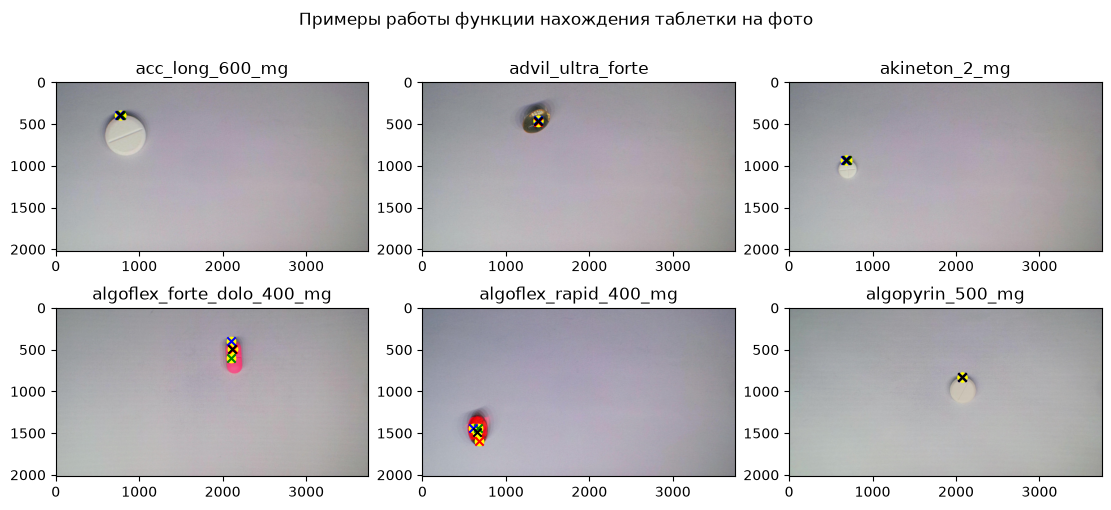

In [24]:
fig, axes = plt.subplots(2,3, figsize=(11,5), layout='constrained')
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = Image.open(os.path.join(
                path_dataset_test,
                classes_decoder[i],
                os.listdir(os.path.join(path_dataset_test,classes_decoder[i]))[0]))
    ax.imshow(image)
    ax.set_title(classes_decoder[i])
    tablet_here = find_tablet(image)
    ax.scatter(tablet_here[:,1], tablet_here[:,0], color='yellow', marker='o')
    ax.scatter(tablet_here[1,1], tablet_here[1,0], color='red',    marker='x')
    ax.scatter(tablet_here[2,1], tablet_here[2,0], color='green',  marker='x')
    ax.scatter(tablet_here[3,1], tablet_here[3,0], color='blue',   marker='x')
    ax.scatter(tablet_here[0,1], tablet_here[0,0], color='black',  marker='x')

fig.suptitle('Примеры работы функции нахождения таблетки на фото\n')
plt.show()

**работает стабильно, но с белыми таблетками при направленном освещении попадает на самый контрастный край таблетки, что увеличивает размер фрагмента с гарантированным попаданием всей таблетки (не факт, что оно нужно!)**

### теперь посмотрим как будет вырезать

In [ ]:

def crop_fixed_window_around_tablet(image, crop_half=2*224):
    np_img = np.array(image)       # как массив

    # Центр таблетки
    ch, cw = find_tablet(image)[0]

    x1 = cw - crop_half
    y1 = ch - crop_half
    x2 = x1 + 2*crop_half
    y2 = y1 + 2*crop_half

    # Padding если вышли за границы
    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - np_img.shape[1])
    pad_bottom = max(0, y2 - np_img.shape[0])

    x1 += pad_left + pad_right
    x2 += pad_left + pad_right
    y1 += pad_top + pad_bottom
    y2 += pad_top + pad_bottom

    np_crop = np_img[y1:y2, x1:x2]
    
    return Image.fromarray(np_crop)

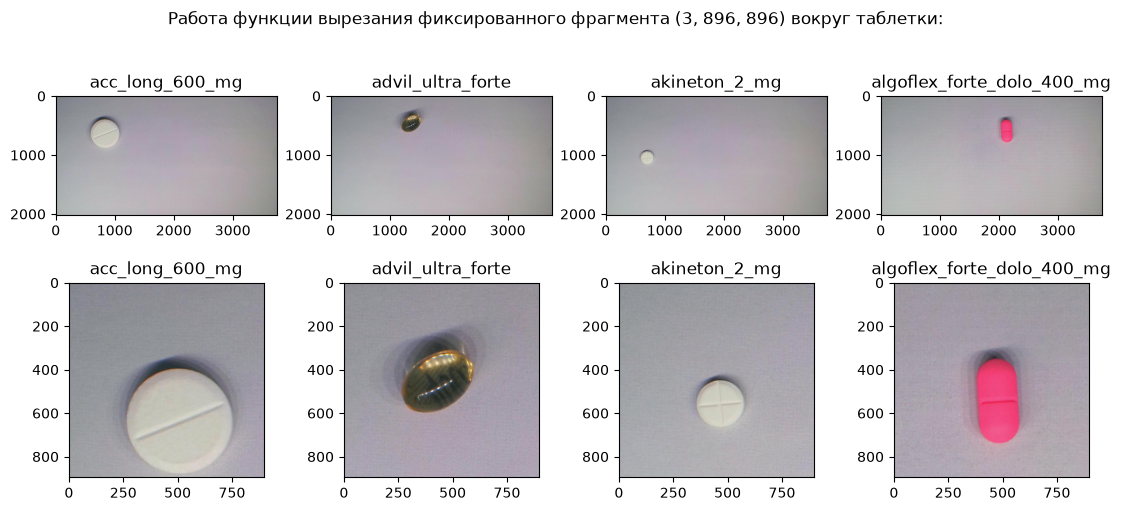

In [26]:
fig, axes = plt.subplots(2,4, figsize=(11,5), layout='constrained')

for i in range(axes.shape[1]):
    image = Image.open(os.path.join(
                path_dataset_test,
                classes_decoder[i],
                os.listdir(os.path.join(path_dataset_test,classes_decoder[i]))[0]))
    axes[0,i].imshow(image)
    axes[0,i].set_title(classes_decoder[i])

    axes[1,i].imshow(crop_fixed_window_around_tablet(image, crop_half_size))
    axes[1,i].set_title(classes_decoder[i])

fig.suptitle('Работа функции вырезания фиксированного фрагмента '+
             str(to_tensor(crop_fixed_window_around_tablet(image, crop_half_size)).detach().numpy().shape)+
             ' вокруг таблетки:\n')
plt.show()

In [27]:
print('Без потерь разрешения мы уменьшили картинку на', 
      round((2019*3746 - 4*crop_half_size*crop_half_size)/2019/3746*100,1), 
      '%, удалением пустого фона!')

Без потерь разрешения мы уменьшили картинку на 89.4 %, удалением пустого фона!


# Этап 1. Пайплайн предобработки изображений в объекты pyTorch: Dataset и DataLoader

## обернем функцию обрезания фото вокруг таблетки в класс (с которым работает `Compose` торча)

In [ ]:
class CropTablet:
    def __init__(self, crop_half=crop_half_size):
        self.crop_half = crop_half

    def __call__(self, image):
        return crop_fixed_window_around_tablet(
            image,
            crop_half=self.crop_half
        )

## определим трансформации для датасетов

In [ ]:

train_transforms = Compose([
    CropTablet(crop_half=crop_half_size),
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5]),
    Resize((model_resize_img, model_resize_img)),
    ToTensor(),
    Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

test_transforms = Compose([
    CropTablet(crop_half=crop_half_size),
    Resize((model_resize_img, model_resize_img)),
    ToTensor(),
    Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])